In [11]:
import numpy as np
import xarray as xr
from einops import rearrange
import random 
import matplotlib.pyplot as plt
import torch 
raw_all = np.stack([
    np.load('data/state0.npy'),
    np.load('data/state1.npy'),
    np.load('data/state2.npy')
], axis=0)  # (3, 325, 7, 5000, 2)

da_all = xr.DataArray(
    raw_all, 
    dims = ['state', 'time', 'qubit', 'shot', 'iq'],
    coords={'state': [0, 1, 2] }
    )
drift_q0 = da_all.isel(qubit=0) 
min_val = drift_q0.min(dim=['state', 'shot'])
max_val = drift_q0.max(dim=['state', 'shot']) 

drift_norm = (drift_q0 - min_val) / (max_val - min_val)#(3, 325, 5000, 2)
X = rearrange(drift_norm.values, 'state time shot iq -> time (state shot) iq')


label_grid = np.broadcast_to(np.array([0, 1, 2])[:, None,  None], 
                             (da_all.state.size, da_all.time.size, da_all.shot.size))  # (3, 325, 5000)

Y = rearrange(label_grid, 'state time shot -> time (state shot)')  # (325, 15000)



In [12]:
SEED = 2026
SPLIT_RATIO = 0.8
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

N_SHOTS= X.shape[1]
IDX = np.random.permutation(N_SHOTS) #clearer than np.arange + np.random.suffle
N_train = int(SPLIT_RATIO * N_SHOTS)
TRAIN_IDX = IDX[:N_train]
TEST_IDX = IDX[N_train:]


X_t = torch.from_numpy(X).float()
Y_t = torch.from_numpy(Y).long()
X_tr, Y_tr = X_t[:, TRAIN_IDX, :], Y_t[:, TRAIN_IDX]
X_te, Y_te = X_t[:, TEST_IDX, :], Y_t[:, TEST_IDX]

# Calling list() on a PyTorch tensor automatically unbinds the 0th dimension (Time).
train_x = list(X_tr)
train_y = list(Y_tr)
test_x = list(X_te)
test_y = list(Y_te)

Rendering animation...


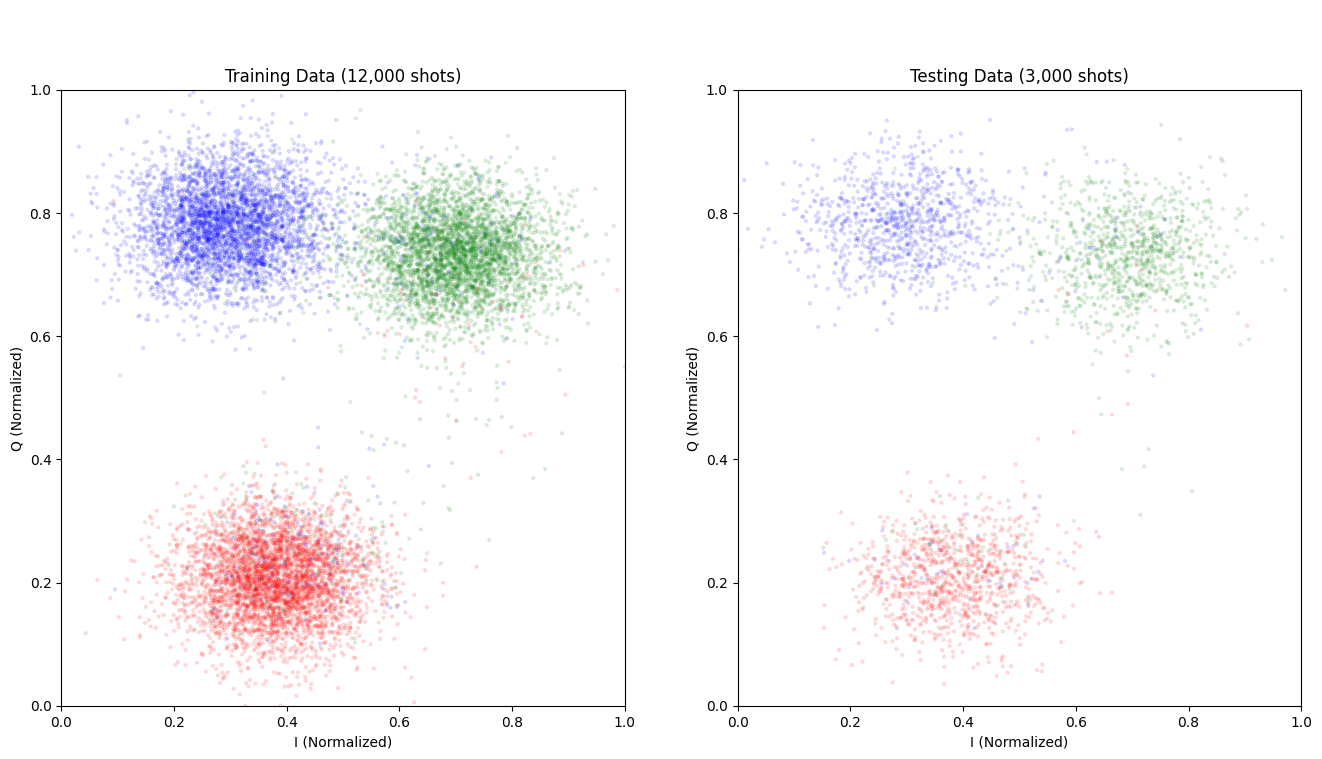

In [13]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# 1. FIX THE CAMERA (Calculate Global Bounds)
x_min, x_max = X_t[..., 0].min().item(), X_t[..., 0].max().item()
y_min, y_max = X_t[..., 1].min().item(), X_t[..., 1].max().item()

# 2. SETUP THE DUAL CANVAS
# Create a 1x2 grid of subplots. figsize=(16, 8) ensures they remain square.
fig, (ax_tr, ax_te) = plt.subplots(1, 2, figsize=(16, 8))

# The Super Title will act as our global timestep counter
time_text = fig.suptitle("IQ Plane Drift | t = 0", fontsize=16)

# Apply identical formatting to both axes programmatically
for ax, title in zip([ax_tr, ax_te], ["Training Data (12,000 shots)", "Testing Data (3,000 shots)"]):
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(title)
    ax.set_xlabel("I (Normalized)")
    ax.set_ylabel("Q (Normalized)")
    # Optional: lock aspect ratio to 'equal' if you want true physical circles
    # ax.set_aspect('equal')

# 3. PRE-COMPUTE STATIC COLORS
color_map = {0: 'red', 1: 'green', 2: 'blue'}
colors_tr = [color_map[y.item()] for y in Y_tr[0]]
colors_te = [color_map[y.item()] for y in Y_te[0]]

# 4. INSTANTIATE THE ARTISTS ONCE (Using t=0 data)
x_tr_0 = X_tr[0, :, 0].cpu().numpy()
y_tr_0 = X_tr[0, :, 1].cpu().numpy()
x_te_0 = X_te[0, :, 0].cpu().numpy()
y_te_0 = X_te[0, :, 1].cpu().numpy()

# We can now use identical styling for both, making true 1-to-1 comparison easy
scat_tr = ax_tr.scatter(x_tr_0, y_tr_0, c=colors_tr, marker='o', alpha=0.1, s=5)
scat_te = ax_te.scatter(x_te_0, y_te_0, c=colors_te, marker='o', alpha=0.1, s=5)

# 5. THE OPTIMIZED UPDATE LOOP
def init():
    """Returns the t=0 state as the baseline for the blitting engine."""
    return scat_tr, scat_te, time_text

def update(frame):
    """Updates the coordinates on both axes and the global title."""
    scat_tr.set_offsets(X_tr[frame].cpu().numpy())
    scat_te.set_offsets(X_te[frame].cpu().numpy())
    
    time_text.set_text(f"IQ Plane Drift | t = {frame}")
    
    return scat_tr, scat_te, time_text

# 6. COMPILE THE ANIMATION
ani = animation.FuncAnimation(
    fig, 
    update, 
    frames=X_t.shape[0], # 325 frames
    init_func=init, 
    blit=True, 
    interval=50 
)

# 7. EXPORT
print("Rendering animation...")
#ani.save('iq_drift_dual.gif', writer='pillow', fps=20)
ani.save('iq_drift_dual.mp4', fps=20, extra_args=['-vcodec', 'libx264'])


In [3]:
len(train_x), len(train_y), len(test_x), len(test_y)

(325, 325, 325, 325)

In [ ]:
from avalanche.benchmarks import tensors_benchmark
from avalanche.models import SimpleMLP
from avalanche.training.supervised import Naive, Replay
from avalanche.training.plugins import EvaluationPlugin
from avalanche.evaluation.metrics import accuracy_metrics, loss_metrics
from avalanche.logging import InteractiveLogger, TensorboardLogger
from torch.nn import CrossEntropyLoss
from torch.optim import SGD
from avalanche.training.plugins import ReplayPlugin
from avalanche.training.storage_policy import ExperienceBalancedBuffer

scenario = tensors_benchmark(
    train_tensors=list(zip(train_x, train_y)),
    test_tensors=list(zip(test_x, test_y)),
    task_labels=[0] * len(train_x)
)


# def run_qubit_experiment(strategy_name, replay_mem_size=600):
#     print(f"--- Starting Experiment: {strategy_name} ---")
    
#     # LOGGERS: Tensorboard for graphs, Interactive for clean terminal
#     # InteractiveLogger: we set it to quiet mode by limiting metric frequency
#     tb_logger = TensorboardLogger(f"logs/{strategy_name}")
#     int_logger = InteractiveLogger()
    
#     # EVALUATION PLUGIN: We only track Experience accuracy to keep it "quiet"
#     # Setting minibatch=False and epoch=False removes the wordy output
#     eval_plugin = EvaluationPlugin(
#         accuracy_metrics(minibatch=False, epoch=False, experience=True, stream=True),
#         loss_metrics(minibatch=False, epoch=False, experience=True, stream=True),
#         loggers=[int_logger, tb_logger]
#     )
    
#     model = SimpleMLP(input_size=2, num_classes=3, hidden_size=16)
    
#     if 'naive' in strategy_name:
#         strategy = Naive(
#             model, SGD(model.parameters(), lr=0.01), CrossEntropyLoss(),
#             train_mb_size=256, train_epochs=1, evaluator=eval_plugin
#         )
#         print('NAIVE is running')
#     elif 'replay' in strategy_name:
#         # Replay uses a small buffer (200) to track the rotation
#         strategy = Replay(
#             model, SGD(model.parameters(), lr=0.01), CrossEntropyLoss(),
#             mem_size=replay_mem_size, train_mb_size=256, train_epochs=1, evaluator=eval_plugin
#         )
#         print('REPLAY is running')
#     # TRAINING & EVALUATION STREAM
#     for i, exp in enumerate(scenario.train_stream):
#         # 1. Feed-while-training: Train on the current 30-min window
#         strategy.train(exp)
        
#         # 2. Evaluate ONLY on the corresponding test window to check drift tracking
#         strategy.eval(scenario.test_stream[i])


def run_qubit_experiment_fixed(strategy_name):
    print(f"--- Starting Experiment: {strategy_name} ---")
    
    tb_logger = TensorboardLogger(f"logs/{strategy_name}")
    int_logger = InteractiveLogger()
    
    # We want to track the accuracy of the stream
    eval_plugin = EvaluationPlugin(
        accuracy_metrics(experience=True, stream=True),
        loss_metrics(experience=True, stream=True),
        loggers=[int_logger, tb_logger]
    )
    
    model = SimpleMLP(input_size=2, num_classes=3, hidden_size=16)
    
    # THE TRACKING OPTIMIZER
    # Momentum = 0.9 acts as a moving average, smoothing out sudden hardware noise
    # Weight Decay prevents the model from perfectly overfitting local anomalies
    optimizer = SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
    
    if 'naive' in strategy_name:
        # Naive is actually an excellent baseline for Concept Drift IF 
        # given a robust optimizer, because it naturally overrides old data.
        strategy = Naive(
            model, optimizer, CrossEntropyLoss(),
            train_mb_size=256, train_epochs=1, evaluator=eval_plugin
        )
        
    elif 'replay' in strategy_name:
        # If you want replay, you must override the default Reservoir sampling
        # Using a small buffer and forcing it to clear/refresh heavily
        storage_policy = ExperienceBalancedBuffer(max_size=600, adaptive_size=True)
        fifo_plugin = ReplayPlugin(mem_size=600, storage_policy=storage_policy)
        
        strategy = Naive(
            model, optimizer, CrossEntropyLoss(),
            train_mb_size=256, train_epochs=1, evaluator=eval_plugin,
            plugins=[fifo_plugin]
        )

    for i, exp in enumerate(scenario.train_stream):
        strategy.train(exp)
        
        # EVALUATION FIX: 
        # If you want to see if it tracks the CURRENT state perfectly:
        #strategy.eval(scenario.test_stream[i])
        
        # If you want to prove to a reviewer that it FORGETS the old drifted states
        # (which is a good thing in this physics context):
        strategy.eval(scenario.test_stream[:i+1])

In [ ]:
#run_qubit_experiment('naive-2026-02-22-2')

In [ ]:
run_qubit_experiment_fixed('naive-forget-2026-02-22-0')

In [ ]:
# fig, ax = plt.subplots(figsize=(8, 6))
# ax.scatter(test_drift0.isel(iq=0), test_drift0.isel(iq=1),s=5, alpha=0.5)
# ax.set_xlabel('I')
# ax.set_ylabel('Q')
# ax.set_title('Drift0 Normalized (Test Set)')
# plt.show()·